# Nudging round 2

Does this way work


In [5]:
import polars as pl
import os
import numpy as np
import itertools

## Load data

### Admissions

In [6]:
path_to_msoa_stats = os.path.join('data', 'msoa_cleaned.csv')

df_stats = pl.read_csv(path_to_msoa_stats)

In [7]:
df_stats.head()

MSOA,admissions,IMD2019Score,All persons,country,good_health,fair health,bad health,prop_good_health,prop_fair health,prop_bad health,MSOA11CD,age_65_proportion,age_70_proportion,age_75_proportion,age_less65_proportion,age_over80_proportion,total_health,age_less65,age_65,age_70,age_75,age_over80,depriv_quantile_min,depriv_quantile_max
str,f64,f64,i64,str,i64,i64,i64,f64,f64,f64,str,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
"""Adur 001""",14.333333,16.924833,8815,"""E""",6799,1251,474,0.79763,0.146762,0.055608,"""E02006534""",0.0559,0.0528,0.0422,0.7872,0.062,8524,6939.168,492.7585,465.432,371.993,546.53,0.4,0.6
"""Adur 002""",7.333333,6.4704,7263,"""E""",5537,838,259,0.83464,0.126319,0.039041,"""E02006535""",0.0578,0.0774,0.0492,0.7467,0.0692,6634,5423.2821,419.8014,562.1562,357.3396,502.5996,0.8,1.0
"""Adur 003""",9.333333,13.7334,7354,"""E""",5820,969,311,0.819718,0.136479,0.043803,"""E02006536""",0.0609,0.0582,0.0421,0.7729,0.0661,7100,5683.9066,447.8586,428.0028,309.6034,486.0994,0.6,0.8
"""Adur 004""",21.0,26.199857,10582,"""E""",7872,1546,709,0.777328,0.152661,0.070011,"""E02006537""",0.0465,0.0438,0.0367,0.8091,0.0638,10127,8561.8962,492.063,463.4916,388.3594,675.1316,0.2,0.4
"""Adur 005""",13.666667,11.7948,9059,"""E""",7106,1081,339,0.833451,0.126789,0.039761,"""E02006538""",0.0597,0.067,0.0425,0.7643,0.0662,8526,6923.7937,540.8223,606.953,385.0075,599.7058,0.6,0.8


Pick out column names for the health and age proportions:

In [8]:
props_age = [
    'age_less65_proportion', 'age_65_proportion', 'age_70_proportion',
    'age_75_proportion', 'age_over80_proportion'
]
age_numbers = [p.replace('_proportion', '') for p in props_age]

In [9]:
qmin_list = sorted(df_stats['depriv_quantile_min'].unique())

In [10]:
# Names of coeffs:
coeff_names = [f'{a}_q{str(round(q, 1)).replace(".", "")}' for q in qmin_list for a in age_numbers]

coeff_names

['age_less65_q00',
 'age_65_q00',
 'age_70_q00',
 'age_75_q00',
 'age_over80_q00',
 'age_less65_q02',
 'age_65_q02',
 'age_70_q02',
 'age_75_q02',
 'age_over80_q02',
 'age_less65_q04',
 'age_65_q04',
 'age_70_q04',
 'age_75_q04',
 'age_over80_q04',
 'age_less65_q06',
 'age_65_q06',
 'age_70_q06',
 'age_75_q06',
 'age_over80_q06',
 'age_less65_q08',
 'age_65_q08',
 'age_70_q08',
 'age_75_q08',
 'age_over80_q08']

In [11]:
quantile_str_list = sorted(list(set([c.split('_')[-1] for c in coeff_names])))
age_str_list = ['age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']

In [12]:
quantile_str_list

['q00', 'q02', 'q04', 'q06', 'q08']

In [13]:
age_str_list

['age_less65', 'age_65', 'age_70', 'age_75', 'age_over80']

Gather admissions data by deprivation quantile:

In [14]:
admissions_lists = []
x_lists = []

for qmin in qmin_list:
    df_stats_here = df_stats.filter(df_stats['depriv_quantile_min'] == qmin)
    # MSOA data in the same order as those coefficients:
    x_lists_here = [df_stats_here[a] for a in age_numbers]
    admissions_here = df_stats_here['admissions'].to_numpy().tolist()
    # Store:
    admissions_lists.append(admissions_here)
    x_lists.append(x_lists_here)

### Age-admissions coefficients

Starting SSNAP coefficients:

In [15]:
df_pop_admissions = pl.read_csv(os.path.join('outputs', 'ssnap_coeffs.csv'))

In [16]:
df_pop_admissions

Age Groups,population,prop_of_all_pop,count,prop_of_all_admissions,admissions_annual,admissions_annual_boost,prob_stroke_given_age
str,i64,f64,i64,f64,f64,f64,f64
"""Under 65""",45933245,0.816055,38827,0.231449,12942.33333,18737.66819,0.000408
"""65-69""",2796740,0.049687,15324,0.091347,5108.0,7395.26689,0.002644
"""70-74""",2779326,0.049378,21508,0.12821,7169.33333,10379.62674,0.003735
"""75-79""",1940686,0.034478,24150,0.143959,8050.0,11654.63948,0.006005
"""80 and over""",2836964,0.050402,67947,0.405035,22649.0,32790.7987,0.011558


Pick out SSNAP coefficients:

In [17]:
coeffs_ssnap = df_pop_admissions['prob_stroke_given_age'].to_numpy()

coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

Turn them into a dictionary:

In [18]:
labels = ['less65', '65', '70', '75', 'over80']
coeffs_ssnap_dict = dict(zip(labels, df_pop_admissions['prob_stroke_given_age'].to_numpy()))

coeffs_ssnap_dict

{'less65': 0.000408,
 '65': 0.002644,
 '70': 0.003735,
 '75': 0.006005,
 'over80': 0.011558}

Pick out admissions numbers:

In [19]:
dict_admissions_age = dict(zip(df_pop_admissions['Age Groups'], df_pop_admissions['admissions_annual_boost']))

admissions_by_age = list(dict_admissions_age.values())

dict_admissions_age

{'Under 65': 18737.66819,
 '65-69': 7395.26689,
 '70-74': 10379.62674,
 '75-79': 11654.63948,
 '80 and over': 32790.7987}

### Best results from genetic algorithm

Data stored as scale factors for the SSNAP-derived coefficients.

In [20]:
df_best_gens = pl.read_csv(os.path.join('outputs', 'best_inds_deap.csv'))

In [21]:
df_best_gens.head()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness,r2_all,r2_q00,r2_q02,r2_q04,r2_q06,r2_q08
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed00""",33.0,1.3,1.2,1.332,1.237,1.2,1.026,1.145,1.151,1.041,1.1,1.0,1.0,0.988,0.938,1.0,0.862,0.9,0.945,0.938,0.937,0.8,0.9,0.732,0.832,0.874,238.372,0.584365,0.502719,0.579147,0.616005,0.598245,0.606993
"""randomseed01""",33.0,1.1,1.3,1.305,1.3,1.231,1.1,1.1,1.1,1.023,1.1,1.0,1.0,1.0,1.0,1.0,0.969,0.9,0.9,0.892,0.9,0.837,0.849,0.8,0.8,0.894,238.507,0.575882,0.471584,0.579147,0.616005,0.583824,0.606993
"""randomseed02""",43.0,1.273,1.308,1.175,1.2,1.214,0.981,1.1,1.103,1.1,1.131,0.949,0.987,1.046,1.0,1.0,0.949,0.979,0.896,0.9,0.9,0.844,0.773,0.861,0.8,0.88,238.037,0.58383,0.485431,0.583466,0.616005,0.606683,0.606993
"""randomseed03""",28.0,1.171,1.3,1.327,1.186,1.3,1.1,1.198,1.1,1.1,1.1,1.042,1.0,1.0,1.0,0.971,0.881,0.9,0.894,1.0,0.9,0.8,0.771,0.808,0.7,0.9,239.49,0.585993,0.508469,0.583466,0.631482,0.605116,0.580367
"""randomseed04""",39.0,1.2,1.2,1.25,1.225,1.293,1.1,1.1,1.11,1.069,1.1,0.976,1.019,1.0,1.0,0.961,0.925,0.904,0.9,0.915,0.91,0.8,0.9,0.844,0.8,0.879,238.453,0.591769,0.508469,0.579147,0.631482,0.612783,0.606993


Convert the scale factors to the actual age-deprivation coefficient values using the SSNAP coefficients.

In [22]:
for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = df_best_gens[coeff] * coeffs_ssnap_dict[key]
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Round results:

In [23]:
labels = ['less65', '65', '70', '75', 'over80']
round_dict = dict(zip(labels, [4, 3, 3, 3, 3]))  # [5, 4, 4, 4, 4]

for coeff in coeff_names:
    key = coeff.split('_')[1]
    new_data = np.round(df_best_gens[coeff], round_dict[key])
    
    df_best_gens = df_best_gens.with_columns(pl.Series(coeff, new_data))

Drop the fitness measure:

In [24]:
df_best_gens = df_best_gens.drop(['fitness'] + [c for c in df_best_gens.columns if c.startswith('r2')])

## Recalculate fitness:

In [26]:
# Calculate fitness:

In [27]:
def predict_admissions(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    # yhat = (x_lists * coeffs.reshape(len(coeffs), 1)).sum(axis=0)
    yhat = sum(
        [x_lists[i] * coeffs[i] for i in range(len(coeffs))]
    )
    return yhat.to_numpy().tolist()

In [28]:
def predict_admissions_each_age(x_lists, coeffs):
    """
    x_lists: np.array.
    coeffs: np.array.
    
    Have to have same number of coeffs as x_lists.
    """
    # Predicted admissions:
    yhat = (
        [(x_lists[i] * coeffs[i]).sum() for i in range(len(coeffs))]
    )
    return yhat

Goodness check option 1: This calculates the sum of the square of the differences between predicted and actual admission numbers:

In [29]:
def find_square_residuals(yhat, y):
    # Difference from actual:
    sqres = (np.array(yhat) - np.array(y))**2.0
    # Sum of differences:
    sum_sqres = sqres.sum()
    return np.sqrt(sum_sqres)

In [30]:
# the goal ('fitness') function to be maximized
def eval_admissions(individual, admissions_lists, x_lists, admissions_by_age):

    # Predictions for each age band across England:
    predictions_by_age = [0.0] * 5
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] #* np.array(coeffs_ssnap)
        yhat_list = predict_admissions_each_age(x_lists_here, coeffs)
        # predictions_lists.append(yhat)
        for j, y in enumerate(yhat_list):
            predictions_by_age[j] += y
    # Divide the admissions by age band by the observed values:
    for j in range(len(predictions_by_age)):
        predictions_by_age[j] /= admissions_by_age[j]
    # Wrongness ratio factor:
    rat = sum(np.abs(np.array(predictions_by_age) - 1.0)) + 1.0
    
    # Predictions for each MSOA:
    predictions_lists = []
    sum_sqres_by_depriv = []
    for i in range(5):
        # Population numbers for areas in this quantile:
        x_lists_here = x_lists[i]
        # Separate prediction for each deprivation quantile:
        coeffs = individual[(i*5):(i*5)+5] #* np.array(coeffs_ssnap)
        yhat = predict_admissions(x_lists_here, coeffs)
        predictions_lists.append(yhat)
        sum_sqres = find_square_residuals(yhat, admissions_lists[i])
        sum_sqres_by_depriv.append(sum_sqres)

    # Combine lists:
    observed_all = sum(admissions_lists, [])
    predicted_all = sum(predictions_lists, [])
    # Use only one of the following options for checking the fit:
    sum_sqres = find_square_residuals(predicted_all, observed_all)
    # sum_sqres = find_mean_abs_diff(yhat, admissions)

    # Apply wrongness factor:
    # sum_sqres *= rat
    
    return (sum_sqres, rat, sum_sqres * rat, predictions_by_age, sum_sqres_by_depriv)

In [31]:
fitnesses = []

for d in range(len(df_best_gens)):
    df = df_best_gens[d]
    # Pick out coefficients:
    coeffs = df[coeff_names].to_numpy().flatten()
    sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
        coeffs,
        admissions_lists,
        x_lists,
        admissions_by_age
    )
    fitnesses.append(fitness)

In [32]:
df_best_gens = df_best_gens.with_columns(pl.Series('fitness', fitnesses))

View results:

In [33]:
df_best_gens.sort('fitness').head()

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed74""",22.0,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,252.546109
"""randomseed10""",26.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,252.980542
"""randomseed94""",18.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,253.361768
"""randomseed26""",20.0,0.0005,0.004,0.005,0.008,0.014,0.0004,0.003,0.004,0.006,0.014,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,254.161938
"""randomseed57""",56.0,0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.006,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.006,0.01,0.0003,0.002,0.003,0.005,0.01,254.262948


## Set up offsets

Allow these offsets for the coeffs:

In [34]:
offsets = np.array([1e-4, 1e-3, 1e-3, 1e-3, 1e-3] * 5)

What probability of no change do we need to have an average of 3 coeffs changing?

In [106]:
((25.0 - 3.0)/25.0)

0.88

Set up changes:

In [107]:
seeds_list = []
random_offsets = []
for seed in np.arange(10000):
    np.random.seed(seed)
    r = list(offsets * np.random.choice(np.arange(-2, 3, 1), 25, p=[0.02, 0.04, 0.88, 0.04, 0.02]))
    if r not in random_offsets:
        random_offsets.append(r)
        seeds_list.append(seed)

In [108]:
len(random_offsets)

7730

Mean number of offsets won't be 3 as requested because we've deleted all the extra copies of repeat offsets (e.g. all are zero).

In [109]:
np.mean(np.sum(np.array(random_offsets) > 0, axis=1))

1.798059508408797

In [110]:
np.mean(np.sum(np.array(random_offsets) < 0, axis=1))

1.7707632600258731

In [111]:
np.mean(np.sum(np.array(random_offsets) != 0, axis=1))

3.56882276843467

In [112]:
coeffs = df_best_gens.sort('fitness')[coeff_names][0].to_numpy().flatten()
results = [list(coeffs)]
seeds_used = [-42]

for s, seed in enumerate(seeds_list):
    r = coeffs + random_offsets[s]
    # Check if rules are met - coeffs increase with age and depriv:
    r_arr = r.reshape(5, 5)
    age_increases = (np.diff(r_arr, axis=1) >= 0).all()
    depriv_increases = (np.diff(r_arr, axis=0) <= 0).all()

    if age_increases & depriv_increases:
        if list(r) not in results:
            results.append(list(r))
            seeds_used.append(seed)

In [113]:
df_nudged = pl.DataFrame(results, schema=coeff_names, orient='row')
df_nudged = df_nudged.insert_column(0, pl.Series('seed', seeds_used))

In [114]:
len(df_nudged)

640

In [115]:
df_nudged.head()

seed,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-42,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
2,0.0005,0.003,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
27,0.0005,0.004,0.004,0.007,0.014,0.0005,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
32,0.0005,0.004,0.004,0.008,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
37,0.0006,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.004,0.005,0.01,0.0002,0.002,0.003,0.005,0.01


In [116]:
eval_dict = {}
eval_labels = [
    'sum_sqres',
    'wrong_rat',
    'fitness',
    'wrong_rat_under65',
    'wrong_rat_65',
    'wrong_rat_70',
    'wrong_rat_75',
    'wrong_rat_over80',
    'sum_sqres_q00',
    'sum_sqres_q02',
    'sum_sqres_q04',
    'sum_sqres_q06',
    'sum_sqres_q08',
]
eval_dict = dict(zip(eval_labels, [[] for e in eval_labels]))

for d in range(len(df_nudged)):
    df = df_nudged[d]
    # Pick out coefficients:
    coeffs = df[coeff_names].to_numpy().flatten()
    sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
        coeffs,
        admissions_lists,
        x_lists,
        admissions_by_age
    )
    eval_dict['sum_sqres'].append(sum_sqres)
    eval_dict['wrong_rat'].append(rat)
    eval_dict['fitness'].append(fitness)
    eval_dict['wrong_rat_under65'].append(ratios_by_age[0])
    eval_dict['wrong_rat_65'].append(ratios_by_age[1])
    eval_dict['wrong_rat_70'].append(ratios_by_age[2])
    eval_dict['wrong_rat_75'].append(ratios_by_age[3])
    eval_dict['wrong_rat_over80'].append(ratios_by_age[4])
    eval_dict['sum_sqres_q00'].append(sum_sqres_by_depriv[0])
    eval_dict['sum_sqres_q02'].append(sum_sqres_by_depriv[1])
    eval_dict['sum_sqres_q04'].append(sum_sqres_by_depriv[2])
    eval_dict['sum_sqres_q06'].append(sum_sqres_by_depriv[3])
    eval_dict['sum_sqres_q08'].append(sum_sqres_by_depriv[4])

In [117]:
for key, v in eval_dict.items():
    df_nudged = df_nudged.with_columns(pl.Series(key, v))

In [118]:
df_nudged[0]

seed,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-42,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.191107,1.055834,252.546109,0.980725,1.01735,1.013293,0.99959,0.994494,111.087199,107.849722,108.96863,104.473782,102.232696


In [119]:
df_nudged.sort('fitness')

seed,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6483,0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.324924,1.045778,249.234929,0.980725,1.007294,1.013293,0.99959,0.994494,111.087199,108.616129,106.276266,104.473782,102.232696
9196,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,239.490857,1.050797,251.656359,0.980725,1.01735,1.013293,0.99959,0.999531,111.087199,109.054005,108.96863,103.908818,102.232696
540,0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.001,0.003,0.005,0.01,241.387779,1.043606,251.913656,0.980725,1.005122,1.013293,0.99959,0.994494,111.087199,108.616129,108.96863,104.473782,106.495527
3575,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.004,0.005,0.011,0.0004,0.002,0.003,0.005,0.01,237.8619,1.060951,252.359804,1.026324,1.01735,1.013293,0.99959,0.996426,111.087199,107.849722,106.750111,103.908818,102.047668
4131,0.0005,0.004,0.004,0.007,0.013,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,239.769863,1.052534,252.365853,0.980725,1.01735,1.013293,0.99959,1.002206,112.850768,107.849722,108.96863,103.908818,102.232696
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6359,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.01,0.0001,0.002,0.003,0.005,0.01,247.203518,1.269717,313.878622,0.889527,1.100629,1.013293,1.039816,0.994494,111.087199,107.849722,108.96863,106.190175,118.267221
1843,0.0004,0.004,0.004,0.008,0.014,0.0004,0.004,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0002,0.002,0.004,0.005,0.01,241.051194,1.30894,315.521473,0.882161,1.086117,1.075628,1.02385,0.994494,114.245468,108.616129,108.96863,104.473782,102.3096
8540,0.0006,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.007,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.002,0.005,0.008,254.437731,1.245959,317.019017,1.03369,1.01735,0.888329,1.035933,0.952685,112.578832,107.849722,112.410625,107.721177,127.251728


In [120]:
ind_orig = list(df_nudged.sort('fitness')['seed'].to_numpy().flatten()).index(-42)

ind_orig

5

In [121]:
fitness_orig = df_nudged.sort('fitness')[ind_orig]['fitness'].to_numpy()[0]

fitness_orig

252.54610914729594

In [122]:
mask = df_nudged['fitness'] <= fitness_orig

df_nudged.filter(mask).mean()

seed,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3980.5,0.0005,0.004,0.004,0.007,0.013833,0.0004,0.003333,0.004,0.007,0.012833,0.0004,0.002833,0.004,0.006,0.011833,0.0004,0.002,0.004,0.005,0.0105,0.000317,0.001833,0.003,0.005,0.01,239.337738,1.051583,251.679452,0.988325,1.013636,1.013293,0.99959,0.996941,111.381127,108.305905,108.150149,104.1913,102.91233


In [123]:
df_nudged.filter(mask).sort('fitness')

seed,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
6483,0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,238.324924,1.045778,249.234929,0.980725,1.007294,1.013293,0.99959,0.994494,111.087199,108.616129,106.276266,104.473782,102.232696
9196,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,239.490857,1.050797,251.656359,0.980725,1.01735,1.013293,0.99959,0.999531,111.087199,109.054005,108.96863,103.908818,102.232696
540,0.0005,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.001,0.003,0.005,0.01,241.387779,1.043606,251.913656,0.980725,1.005122,1.013293,0.99959,0.994494,111.087199,108.616129,108.96863,104.473782,106.495527
3575,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.011,0.0004,0.002,0.004,0.005,0.011,0.0004,0.002,0.003,0.005,0.01,237.8619,1.060951,252.359804,1.026324,1.01735,1.013293,0.99959,0.996426,111.087199,107.849722,106.750111,103.908818,102.047668
4131,0.0005,0.004,0.004,0.007,0.013,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.011,0.0003,0.002,0.003,0.005,0.01,239.769863,1.052534,252.365853,0.980725,1.01735,1.013293,0.99959,1.002206,112.850768,107.849722,108.96863,103.908818,102.232696
-42,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.191107,1.055834,252.546109,0.980725,1.01735,1.013293,0.99959,0.994494,111.087199,107.849722,108.96863,104.473782,102.232696


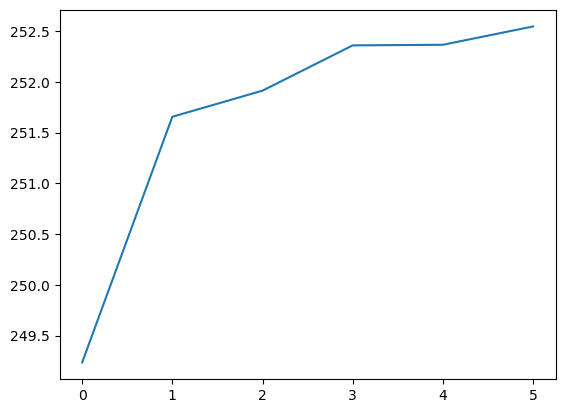

In [124]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(df_nudged.filter(mask).sort('fitness')['fitness'])

plt.show()

In [125]:
df_nudged.sort('fitness')[ind_orig][coeff_names].to_numpy().flatten().reshape(5, 5)

array([[0.0005, 0.004 , 0.004 , 0.007 , 0.014 ],
       [0.0004, 0.003 , 0.004 , 0.007 , 0.013 ],
       [0.0004, 0.003 , 0.004 , 0.006 , 0.012 ],
       [0.0004, 0.002 , 0.004 , 0.005 , 0.01  ],
       [0.0003, 0.002 , 0.003 , 0.005 , 0.01  ]])

In [126]:
for i in range(5):
    print(df_nudged.sort('fitness')[i]['fitness'].to_numpy().flatten()[0])
    print(df_nudged.sort('fitness')[i][coeff_names].to_numpy().flatten().reshape(5, 5))
    print('\n'*2)

249.2349289480491
[[0.0005 0.004  0.004  0.007  0.014 ]
 [0.0004 0.004  0.004  0.007  0.013 ]
 [0.0004 0.002  0.004  0.006  0.012 ]
 [0.0004 0.002  0.004  0.005  0.01  ]
 [0.0003 0.002  0.003  0.005  0.01  ]]



251.65635918394398
[[0.0005 0.004  0.004  0.007  0.014 ]
 [0.0004 0.003  0.004  0.007  0.012 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.002  0.004  0.005  0.011 ]
 [0.0003 0.002  0.003  0.005  0.01  ]]



251.9136564223149
[[0.0005 0.004  0.004  0.007  0.014 ]
 [0.0004 0.004  0.004  0.007  0.013 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.002  0.004  0.005  0.01  ]
 [0.0003 0.001  0.003  0.005  0.01  ]]



252.35980359486783
[[0.0005 0.004  0.004  0.007  0.014 ]
 [0.0004 0.003  0.004  0.007  0.013 ]
 [0.0004 0.003  0.004  0.006  0.011 ]
 [0.0004 0.002  0.004  0.005  0.011 ]
 [0.0004 0.002  0.003  0.005  0.01  ]]



252.36585291351523
[[0.0005 0.004  0.004  0.007  0.013 ]
 [0.0004 0.003  0.004  0.007  0.013 ]
 [0.0004 0.003  0.004  0.006  0.012 ]
 [0.0004 0.002  0

In [81]:
coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

## Optimise age bands

The randomly-picked best fits seem to improve the "wrongness" ratio in the age bands much more than the overall sum of square residuals. So find ways to nudge the coefficients that result in better fits to the total national admissions for each age band.

In [35]:
dict_offsets_for_ages = {  # np.array([1e-4, 1e-3, 1e-3, 1e-3, 1e-3])
    'less65': 1e-4,
    '65': 1e-3,
    '70': 1e-3,
    '75': 1e-3,
    'over80': 1e-3,
}

All combos of offsets for ages:

In [36]:
combo_scales_for_ages = np.array([c for c in itertools.product([-2, -1, 0, 1, 2], repeat=5)])

In [37]:
len(combo_scales_for_ages)

3125

For a set of coeffs, apply these offsets and then recalculate fitness:

In [39]:
def wrong_rat(x_lists_here, coeffs, admissions_by_age):
    # Predictions for each age band across England:
    # Separate prediction for each deprivation quantile:
    # coeffs = individual[(i*5):(i*5)+5] #* np.array(coeffs_ssnap)
    yhat_list = (
        [(x_lists_here[i] * coeffs[i]).sum() for i in range(len(coeffs))]
    )
    predictions_by_age = sum(yhat_list)
    # Divide the admissions by age band by the observed values:
    predictions_by_age /= admissions_by_age_here
    return predictions_by_age

In [40]:
age_bands = ['less65', '65', '70', '75', 'over80']

dict_nudged_dfs = {}
for a, age_band in enumerate(age_bands):
    x_lists_here = [x_lists[i][a] for i in range(5)]  # only data for this age band
    admissions_by_age_here = admissions_by_age[a]
    
    age_cols = [c for c in df_best_gens.columns if f'_{age_band}_' in c]
    age_offset = dict_offsets_for_ages[age_band]
    combo_offsets_for_age = combo_scales_for_ages * age_offset
    
    start_coeffs = df_best_gens.sort('fitness')[0][age_cols].to_numpy().flatten()
    
    # df_nudge_here = pl.DataFrame(schema=age_cols + ['rat'])
    df_nudge_here = pl.DataFrame()
    # rats = []#[] for i in range(5)]
    
    for c, combo in enumerate(combo_offsets_for_age):
        coeffs_here = start_coeffs + np.array(combo)
        # Check that coeffs increase with deprivation:
        if all(np.diff(coeffs_here) <= 0.0) & all(coeffs_here > 0.0):
            rat = wrong_rat(x_lists_here, coeffs_here, admissions_by_age_here)
            abs_rat = abs(1.0 - rat)
            # rats.append(round(rat, 7))
            row = dict(zip(age_cols + ['rat', 'abs_rat'], list(coeffs_here) + [round(rat, 7), round(abs_rat, 7)]))
            # if c == 0:
            #     df_nudge_here = pl.DataFrame(row)
            # else:
            df_nudge_here = pl.concat((df_nudge_here, pl.DataFrame(row)))
        else:
            # Don't calculate results for here.
            pass
    # Store result:
    dict_nudged_dfs[age_band] = df_nudge_here

In [81]:
coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [128]:
coeffs_ssnap_round = [0.0004, 0.003, 0.004, 0.006, 0.012]

In [129]:
i = 0
for key, df in dict_nudged_dfs.items():
    print(key)
    display(df.filter(df[f'age_{key}_q04'] == coeffs_ssnap_round[i]).sort('abs_rat')[:10])
    i += 1

less65


age_less65_q00,age_less65_q02,age_less65_q04,age_less65_q06,age_less65_q08,rat,abs_rat
f64,f64,f64,f64,f64,f64,f64
0.0006,0.0006,0.0004,0.0002,0.0002,0.9996408,0.0003592
0.0006,0.0006,0.0004,0.0003,0.0001,0.999514,0.000486
0.0007,0.0005,0.0004,0.0003,0.0001,1.0012324,0.0012324
0.0007,0.0005,0.0004,0.0002,0.0002,1.0013592,0.0013592
0.0007,0.0004,0.0004,0.0003,0.0002,0.9955844,0.0044156
0.0007,0.0004,0.0004,0.0004,0.0001,0.9954576,0.0045424
0.0006,0.0005,0.0004,0.0003,0.0002,0.993866,0.006134
0.0006,0.0005,0.0004,0.0004,0.0001,0.9937392,0.0062608
0.0007,0.0006,0.0004,0.0002,0.0001,1.0070071,0.0070071


65


age_65_q00,age_65_q02,age_65_q04,age_65_q06,age_65_q08,rat,abs_rat
f64,f64,f64,f64,f64,f64,f64
0.005,0.003,0.003,0.002,0.001,0.9978634,0.0021366
0.004,0.004,0.003,0.002,0.001,1.0051216,0.0051216
0.005,0.004,0.003,0.001,0.001,0.9833508,0.0166492
0.004,0.003,0.003,0.002,0.002,1.01735,0.01735
0.004,0.003,0.003,0.003,0.001,1.0196342,0.0196342
0.006,0.003,0.003,0.001,0.001,0.9760925,0.0239075
0.003,0.003,0.003,0.003,0.002,1.0391208,0.0391208
0.003,0.003,0.003,0.003,0.001,0.9581258,0.0418742
0.003,0.003,0.003,0.002,0.002,0.9558416,0.0441584


70


age_70_q00,age_70_q02,age_70_q04,age_70_q06,age_70_q08,rat,abs_rat
f64,f64,f64,f64,f64,f64,f64
0.006,0.006,0.004,0.003,0.001,0.9991764,0.0008236
0.006,0.006,0.004,0.002,0.002,0.9988826,0.0011174
0.005,0.004,0.004,0.004,0.002,0.9903172,0.0096828
0.005,0.004,0.004,0.003,0.003,0.9900235,0.0099765
0.004,0.004,0.004,0.004,0.003,1.0132933,0.0132933
0.006,0.005,0.004,0.003,0.002,1.0142795,0.0142795
0.006,0.005,0.004,0.004,0.001,1.0145733,0.0145733
0.005,0.005,0.004,0.004,0.001,0.9752141,0.0247859
0.005,0.005,0.004,0.003,0.002,0.9749203,0.0250797


75


age_75_q00,age_75_q02,age_75_q04,age_75_q06,age_75_q08,rat,abs_rat
f64,f64,f64,f64,f64,f64,f64
0.007,0.007,0.006,0.005,0.005,0.9995902,0.0004098
0.007,0.007,0.006,0.006,0.004,0.9992987,0.0007013
0.009,0.008,0.006,0.004,0.004,0.9970786,0.0029214
0.009,0.008,0.006,0.005,0.003,0.9967871,0.0032129
0.008,0.006,0.006,0.005,0.005,0.9941362,0.0058638
0.008,0.006,0.006,0.006,0.004,0.9938447,0.0061553
0.009,0.007,0.006,0.006,0.003,1.0072999,0.0072999
0.009,0.007,0.006,0.005,0.004,1.0075914,0.0075914
0.007,0.006,0.006,0.006,0.005,1.010103,0.010103


over80


age_over80_q00,age_over80_q02,age_over80_q04,age_over80_q06,age_over80_q08,rat,abs_rat
f64,f64,f64,f64,f64,f64,f64
0.015,0.014,0.012,0.011,0.008,1.0000637,0.0000637
0.014,0.012,0.012,0.011,0.01,0.9995308,0.0004692
0.015,0.014,0.012,0.01,0.009,1.0009259,0.0009259
0.014,0.012,0.012,0.012,0.009,0.9986685,0.0013315
0.013,0.013,0.012,0.012,0.009,1.0013433,0.0013433
0.016,0.013,0.012,0.01,0.009,0.9982512,0.0017488
0.013,0.013,0.012,0.011,0.01,1.0022055,0.0022055
0.016,0.012,0.012,0.012,0.008,1.0024256,0.0024256
0.016,0.013,0.012,0.011,0.008,0.9973889,0.0026111


In [130]:
i = 0
dict_nudged_dfs_ssnapq04 = {}
for key, df in dict_nudged_dfs.items():
    dict_nudged_dfs_ssnapq04[key] = df.filter(df[f'age_{key}_q04'] == coeffs_ssnap_round[i]).sort('abs_rat')
    i += 1


gather combos that are pretty good, check for increasing coeffs, calculate r-squared. Try various combos depending on resulting total r-squared by depriv quantile, e.g. if best coeffs all weighted heavily in one quantile and the answer is too high, then pick that quantile first to change to another set of coeffs.

..

In [100]:
# Every combo of the top ten indices:
index_combos = [c for c in itertools.product(range(6), repeat=5)]

In [131]:
fitness_keys = [
    'sum_sqres',
    'wrong_rat',
    'fitness',
    'wrong_rat_under65',
    'wrong_rat_65',
    'wrong_rat_70',
    'wrong_rat_75',
    'wrong_rat_over80',
    'sum_sqres_q00',
    'sum_sqres_q02',
    'sum_sqres_q04',
    'sum_sqres_q06',
    'sum_sqres_q08',
]

df_index_combos = pl.DataFrame()

for i, index_combo in enumerate(index_combos):
    print(f'{i+1:4d} out of {len(index_combos)}', end='\r')
    
    dict_inds = {
        'less65': index_combo[0],
        '65': index_combo[1],
        '70': index_combo[2],
        '75': index_combo[3],
        'over80': index_combo[4]
    }
    
    # Gather coeffs for these inds:
    all_coeff_cols = []
    all_coeffs = []
    for age_band, df in dict_nudged_dfs_ssnapq04.items():
        # 'less65', '65', '70', '75', 'over80'
        # Pick out the coeffs for this age band:
        coeff_cols_here = [c for c in df.columns if c.startswith('age')]
        all_coeff_cols += coeff_cols_here
        all_coeffs += list(df[dict_inds[age_band]][coeff_cols_here].to_numpy().flatten())
    # Order coeffs as usual:
    df_coeffs = pl.DataFrame(np.array(all_coeffs).reshape(1, len(all_coeffs)), schema=all_coeff_cols)
    df_coeffs = df_coeffs[coeff_names]
    coeffs = df_coeffs.to_numpy().flatten().reshape(5, 5)
    # print(coeffs)
    # print('\n')

    # Check that coeffs increase with deprivation:
    if np.all(np.diff(coeffs, axis=1) >= 0.0):
        # Calculate fitness:
        sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
            coeffs.flatten(),
            admissions_lists,
            x_lists,
            admissions_by_age
        )
        # Gather values for results:
        results_values = np.concatenate((coeffs.flatten(), [sum_sqres, rat, fitness], ratios_by_age, sum_sqres_by_depriv))
        df_coeffs = pl.DataFrame(results_values.reshape(1, len(results_values)), schema=coeff_names + fitness_keys)
        # Store result:
        df_index_combos = pl.concat((df_index_combos, df_coeffs))
    else:
        # Don't bother with coeffs that don't increase with deprivation.
        pass

In [132]:
df_index_combos.sort('fitness')

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0007,0.004,0.004,0.007,0.014,0.0004,0.004,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0002,0.001,0.003,0.005,0.01,249.34486,1.023709,255.256694,0.995584,1.005122,1.013293,0.99959,0.999531,120.670912,107.931813,108.96863,103.869578,115.32156
0.0007,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0003,0.002,0.004,0.005,0.011,0.0002,0.002,0.003,0.005,0.01,246.495349,1.035938,255.353854,0.995584,1.01735,1.013293,0.99959,0.999531,120.670912,109.054005,108.96863,103.869578,107.901161
0.0006,0.004,0.004,0.007,0.014,0.0006,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0002,0.002,0.004,0.005,0.011,0.0002,0.002,0.003,0.005,0.01,248.227712,1.031881,256.141575,0.999641,1.01735,1.013293,0.99959,0.999531,112.578832,116.188715,108.96863,109.207891,107.901161
0.0006,0.004,0.004,0.008,0.014,0.0006,0.003,0.004,0.006,0.012,0.0004,0.003,0.004,0.006,0.012,0.0002,0.002,0.004,0.005,0.011,0.0002,0.002,0.003,0.005,0.01,247.776672,1.037335,257.027519,0.999641,1.01735,1.013293,0.994136,0.999531,113.949234,113.866873,108.96863,109.207891,107.901161
0.0007,0.004,0.004,0.007,0.014,0.0005,0.003,0.004,0.007,0.012,0.0004,0.003,0.004,0.006,0.012,0.0002,0.002,0.004,0.005,0.011,0.0002,0.002,0.003,0.005,0.01,248.930102,1.032881,257.115289,1.001359,1.01735,1.013293,0.99959,0.999531,120.670912,109.368827,108.96863,109.207891,107.901161
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0007,0.006,0.006,0.009,0.015,0.0005,0.003,0.006,0.008,0.014,0.0004,0.003,0.004,0.006,0.012,0.0003,0.001,0.003,0.004,0.011,0.0001,0.001,0.001,0.004,0.008,330.92523,1.028949,340.50505,1.001232,0.976093,0.999176,0.997079,1.000064,163.23448,132.570292,108.96863,120.390711,197.289241
0.0007,0.005,0.006,0.009,0.015,0.0005,0.004,0.006,0.008,0.014,0.0004,0.003,0.004,0.006,0.012,0.0003,0.001,0.003,0.005,0.011,0.0001,0.001,0.001,0.003,0.008,335.13149,1.021982,342.498283,1.001232,0.983351,0.999176,0.996787,1.000064,154.250404,141.349918,108.96863,113.984555,208.982028
0.0006,0.005,0.006,0.009,0.015,0.0006,0.004,0.006,0.008,0.014,0.0004,0.003,0.004,0.006,0.012,0.0003,0.001,0.003,0.005,0.011,0.0001,0.001,0.001,0.003,0.008,335.535155,1.021235,342.660396,0.999514,0.983351,0.999176,0.996787,1.000064,136.54163,159.374072,108.96863,113.984555,208.982028


In [134]:
df_index_combos.sort('fitness')[0][coeff_names].to_numpy().reshape(5, 5)

array([[0.0007, 0.004 , 0.004 , 0.007 , 0.014 ],
       [0.0004, 0.004 , 0.004 , 0.007 , 0.012 ],
       [0.0004, 0.003 , 0.004 , 0.006 , 0.012 ],
       [0.0003, 0.002 , 0.004 , 0.005 , 0.011 ],
       [0.0002, 0.001 , 0.003 , 0.005 , 0.01  ]])

In [81]:
coeffs_ssnap

array([0.000408, 0.002644, 0.003735, 0.006005, 0.011558])

In [104]:
df_best_gens.sort('fitness')[0]

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed74""",22.0,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,252.546109


## from previouis noteboks

In [135]:
best_picked_combos_age_depriv = pl.read_csv(os.path.join('outputs', 'coeffs_prob_stroke_given_age_depriv.csv'))

In [136]:
best_picked_combos_age_depriv

depriv_quantile_min,less65,65-70,70-75,75-80,over80,r2
str,f64,f64,f64,f64,f64,f64
"""q00""",0.0004,0.005,0.005,0.007,0.015,0.50965
"""q02""",0.0004,0.003,0.003,0.007,0.014,0.58367
"""q04""",0.0003,0.002,0.002,0.007,0.014,0.64668
"""q06""",0.0003,0.002,0.002,0.006,0.013,0.62468
"""q08""",0.0002,0.002,0.002,0.005,0.013,0.63577


In [139]:
coeffs_age_depriv = best_picked_combos_age_depriv['less65', '65-70', '70-75', '75-80', 'over80'].to_numpy().flatten()

sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
    coeffs_age_depriv,
    admissions_lists,
    x_lists,
    admissions_by_age
)

In [141]:
sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv

(234.30725818335938,
 1.765330628713989,
 413.6297794010807,
 [0.7886319949670322,
  1.0000355372569925,
  0.7031238308286216,
  1.076159732973568,
  1.1808911842790824],
 [110.44211324953078,
  107.82373102586294,
  104.52575654389138,
  102.29704377194534,
  98.4182652788163])

In [140]:
fitness

413.6297794010807

# Break here please

In [ ]:
print(stop, here, please)

## Offsets tests

Generate all combinations of 0/1 for 25 coefficients, and only keep the ones with fewer than 15 1s. 15 is the maximum number of changes we can fit in the 5x5 grid without having more than three values change in any row or column.

In [107]:
change_bool = np.array([c for c in itertools.product([0, 1], repeat=25)])
# Only keep sets with 13 to 15 changes:
# change_bool = change_bool[(np.sum(np.array(change_bool), axis=1) <= 15) & (np.sum(np.array(change_bool), axis=1) >= 13)]
# Only keep sets with up to 9 changes:
change_bool = change_bool[(np.sum(np.array(change_bool), axis=1) == 9)]

In [108]:
len(change_bool)

2042975

Only keep options with no more than 3 changes in any row or column:

In [109]:
print(f'Start: {len(change_bool)}')
for i in range(5):
    # Check i-th row:
    age_check_each_combo = np.sum(change_bool[:, 5*i:5*i+5], axis=1)
    # Only keep options that meet the rules:
    change_bool = change_bool[age_check_each_combo <= 3]
    # Check how many are left:
    print(f'Row {i}: {len(change_bool)}')
    # Check i-th column:
    depriv_check_each_combo = np.sum(change_bool[:, i::5], axis=1)
    # Only keep options that meet the rules:
    change_bool = change_bool[depriv_check_each_combo <= 3]
    # Check how many are left:
    print(f'Col {i}: {len(change_bool)}')

Start: 2042975
Row 0: 1960610
Col 0: 1880310
Row 1: 1800395
Col 1: 1722545
Row 2: 1645080
Col 2: 1569680
Row 3: 1494665
Col 3: 1421715
Row 4: 1349150
Col 4: 1278650


Sort the list so that the first X elements all have 15 on, then 14, then 13:

In [110]:
change_bool = change_bool[np.argsort(np.sum(change_bool, axis=1))[::-1]]

Remove copies of the 13-long and 14-long chains that are the same as 14/15 or 15-long chains respectively but with only one value switched off.

In [111]:
# n_max = np.where(np.sum(change_bool, axis=1) < np.max(np.sum(change_bool, axis=1)))[0][0]

# for i in range(n_max):
#     # Pick out coeffs here:
#     coeffs_max = change_bool[i]
#     # Are any diffs all negative, meaning that the 15-long chain
#     # is the same as a shorter chain but with only additions?
#     diffs = change_bool - coeffs_max
#     mask = np.all(diffs <= 0, axis=1)
#     # Remove those ones:
#     change_bool = change_bool[~mask]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
len(change_bool)

In [ ]:
for i in range(10):
    print(change_bool[i].reshape(5, 5))
    print('')

In [4]:
offset_unordered_combos = [c for c in itertools.product([-2, -1, 0, 1, 2], repeat=15)]

KeyboardInterrupt: 

In [ ]:
len(offset_unordered_combos)

In [ ]:
offset_unordered_combos

## Pair-wise nudging

Try all pairs of nudges in each row and column. Pick the one that has best effect on fitness. Then find best pair to match whatever has already changed. Keep iterating until no more improvements can be made.

Set up pair indices.

In [149]:
row_col_inds = [c for c in itertools.product(range(5), repeat=2)]

row_col_inds

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4)]

In [223]:
def build_nudge_df(start_coeffs, first_pass=False):
    """
    """
    def convert_to_dataframe(coeffs_here, nudged_cols):
        """
        """
        # Convert to dataframe:
        data_here = coeffs_here.flatten()
        df_here = pl.DataFrame(np.array(data_here).reshape(1, len(data_here)), schema=nudged_cols)
        return df_here
    
    nudged_cols = coeff_names
    
    df_nudges = pl.DataFrame()
    
    # coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
    # # Store result:
    # df_here = convert_to_dataframe(coeffs_here, nudged_cols)
    # df_nudges = pl.concat((df_nudges, df_here))
    if first_pass:
        # Force two coeffs to change.
          m_pairs_available = [(1.0, -1.0), (-1.0, 1.0)]
    else:
        # Only one coeff has to change, but two are allowed to.
        m_pairs_available = [(1.0, -1.0), (-1.0, 1.0), (1.0, 0.0), (0.0, 1.0), (-1.0, 0.0), (0.0, -1.0)]
    
    for r, (row_a, col_a) in enumerate(row_col_inds[:3]):
        step_a = 1e-4 if col_a == 0 else 1e-3
        # Compare with each other point in the same row:
        for col_b in range(5):
            if col_b != col_a:
                step_b = 1e-4 if col_b == 0 else 1e-3
                for m_pairs in m_pairs_available:
                    # Nudge coefficients:
                    coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
                    coeffs_here[row_a, col_a] += m_pairs[0]*step_a
                    coeffs_here[row_a, col_b] += m_pairs[1]*step_b
                    # Store result:
                    df_here = convert_to_dataframe(coeffs_here, nudged_cols)
                    df_nudges = pl.concat((df_nudges, df_here))
        for row_b in range(5):
            if row_b != row_a:
                # Same step size.
                for m_pairs in m_pairs_available:
                    # Nudge coefficients:
                    coeffs_here = np.array([s for s in start_coeffs]).reshape(5, 5)
                    coeffs_here[row_a, col_a] += m_pairs[0]*step_a
                    coeffs_here[row_b, col_a] += m_pairs[1]*step_a
        
                    # Store result:
                    df_here = convert_to_dataframe(coeffs_here, nudged_cols)
                    df_nudges = pl.concat((df_nudges, df_here))
    # Remove repeats
    # (from comparing A then B and also B then A):
    df_nudges = df_nudges.unique()
    return df_nudges

In [224]:
def find_nudged_fitnesses(df_nudges):
    df_nudges_fitness = pl.DataFrame()
    
    fitness_keys = [
        'sum_sqres',
        'wrong_rat',
        'fitness',
        'wrong_rat_under65',
        'wrong_rat_65',
        'wrong_rat_70',
        'wrong_rat_75',
        'wrong_rat_over80',
        'sum_sqres_q00',
        'sum_sqres_q02',
        'sum_sqres_q04',
        'sum_sqres_q06',
        'sum_sqres_q08',
    ]
    for i in range(len(df_nudges)):
        coeffs = df_nudges[i][coeff_names].to_numpy().flatten()
        
        if np.all(np.diff(coeffs.reshape(5, 5), axis=1) >= 0.0) & np.all(np.diff(coeffs.reshape(5, 5), axis=0) <= 0.0):
            sum_sqres, rat, fitness, ratios_by_age, sum_sqres_by_depriv = eval_admissions(
                coeffs,
                admissions_lists,
                x_lists,
                admissions_by_age
            )
        else:        
            # Overwrite results if coeffs invalid:
            sum_sqres = np.nan
            rat = np.nan
            fitness = np.nan
            ratios_by_age = [np.nan] * 5
            sum_sqres_by_depriv = [np.nan] * 5
    
        # Gather values for results:
        results_values = np.concatenate((coeffs.flatten(), [sum_sqres, rat, fitness], ratios_by_age, sum_sqres_by_depriv))
        df_coeffs = pl.DataFrame(results_values.reshape(1, len(results_values)), schema=coeff_names + fitness_keys)
        # Store result:
        df_nudges_fitness = pl.concat((df_nudges_fitness, df_coeffs))
    return df_nudges_fitness

In [225]:
start_coeffs = df_best_gens.sort('fitness')[0][coeff_names].to_numpy().flatten()
df_nudge_history = find_nudged_fitnesses(pl.DataFrame(start_coeffs.reshape(1, len(start_coeffs)), schema=coeff_names))

keep_going_please = True
k = 0
while keep_going_please:
    first_pass = False if k > 0 else True
    df_nudges = build_nudge_df(start_coeffs, first_pass)
    df_nudges = find_nudged_fitnesses(df_nudges)
    # Pick out the best one:
    df_nudges = df_nudges.sort('fitness')[0]  # CONSIDER not doing fitness, separate r2 or wrong rat depending on whether row or col changed?
    start_coeffs = df_nudges[coeff_names].to_numpy().flatten()
    df_nudge_history = pl.concat((df_nudge_history, df_nudges))
    k += 1
    if (k > 2) & (len(df_nudge_history) != len(df_nudge_history.unique()))):
        keep_going_please = False
    elif k > 100:
        keep_going_please = False
        print('Cutting off after 100 iterations.')

In [226]:
with pl.Config(set_tbl_rows=12):
    display(df_nudge_history)

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,sum_sqres,wrong_rat,fitness,wrong_rat_under65,wrong_rat_65,wrong_rat_70,wrong_rat_75,wrong_rat_over80,sum_sqres_q00,sum_sqres_q02,sum_sqres_q04,sum_sqres_q06,sum_sqres_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.191107,1.055834,252.546109,0.980725,1.01735,1.013293,0.99959,0.994494,111.087199,107.849722,108.96863,104.473782,102.232696
0.0005,0.004,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,240.357618,1.052517,252.980542,0.980725,1.01735,0.990024,0.99959,0.994494,110.501962,107.849722,108.96863,107.721177,102.232696
0.0005,0.005,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.508351,1.035203,247.939719,0.980725,1.000036,0.990024,0.99959,0.994494,111.277433,107.849722,106.276266,107.721177,102.232696
0.0005,0.005,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,240.437787,1.036522,249.219007,0.980725,1.000036,0.990024,0.99959,1.006825,113.264056,107.849722,106.276266,107.721177,102.232696
0.0005,0.005,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,239.508351,1.035203,247.939719,0.980725,1.000036,0.990024,0.99959,0.994494,111.277433,107.849722,106.276266,107.721177,102.232696
0.0005,0.005,0.005,0.007,0.015,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.003,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,240.437787,1.036522,249.219007,0.980725,1.000036,0.990024,0.99959,1.006825,113.264056,107.849722,106.276266,107.721177,102.232696


In [195]:
df_best_gens.sort('fitness')[0][coeff_names].to_numpy().flatten().reshape(5, 5)

array([[0.0005, 0.004 , 0.004 , 0.007 , 0.014 ],
       [0.0004, 0.003 , 0.004 , 0.007 , 0.013 ],
       [0.0004, 0.003 , 0.004 , 0.006 , 0.012 ],
       [0.0004, 0.002 , 0.004 , 0.005 , 0.01  ],
       [0.0003, 0.002 , 0.003 , 0.005 , 0.01  ]])

In [227]:
df_nudge_history.sort('fitness')[0][coeff_names].to_numpy().flatten().reshape(5, 5)

array([[0.0005, 0.005 , 0.005 , 0.007 , 0.014 ],
       [0.0004, 0.003 , 0.004 , 0.007 , 0.013 ],
       [0.0004, 0.002 , 0.004 , 0.006 , 0.012 ],
       [0.0004, 0.002 , 0.003 , 0.005 , 0.01  ],
       [0.0003, 0.002 , 0.003 , 0.005 , 0.01  ]])

In [178]:
df_best_gens.sort('fitness')[0]

dir,# gen,age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08,fitness
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""randomseed74""",22.0,0.0005,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01,252.546109


In [145]:
start_coeffs.reshape(5, 5)

array([[0.0005, 0.004 , 0.004 , 0.007 , 0.014 ],
       [0.0004, 0.003 , 0.004 , 0.007 , 0.013 ],
       [0.0004, 0.003 , 0.004 , 0.006 , 0.012 ],
       [0.0004, 0.002 , 0.004 , 0.005 , 0.01  ],
       [0.0003, 0.002 , 0.003 , 0.005 , 0.01  ]])

In [169]:
df_nudges#.unique()

age_less65_q00,age_65_q00,age_70_q00,age_75_q00,age_over80_q00,age_less65_q02,age_65_q02,age_70_q02,age_75_q02,age_over80_q02,age_less65_q04,age_65_q04,age_70_q04,age_75_q04,age_over80_q04,age_less65_q06,age_65_q06,age_70_q06,age_75_q06,age_over80_q06,age_less65_q08,age_65_q08,age_70_q08,age_75_q08,age_over80_q08
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0005,0.005,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.001,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
0.0006,0.004,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0003,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
0.0005,0.005,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.002,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
0.0005,0.004,0.005,0.007,0.013,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
0.0006,0.004,0.004,0.007,0.013,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0005,0.003,0.005,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
0.0005,0.005,0.004,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.001,0.003,0.005,0.01
0.0005,0.005,0.003,0.007,0.014,0.0004,0.003,0.004,0.007,0.013,0.0004,0.003,0.004,0.006,0.012,0.0004,0.002,0.004,0.005,0.01,0.0003,0.002,0.003,0.005,0.01
